# Manufacturing Failure Analysis - Simple EDA & Statistical Validation

This notebook analyzes the manufacturing failure dataset using **simple code only** (no scikit-learn):
- Data understanding
- Feature engineering (basic derived features)
- Hypothesis testing (t-tests, chi-square, correlations)
- Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('default')
sns.set_palette('husl')
np.set_printoptions(suppress=True)

## 1. Data Loading & Understanding

In [2]:
data = pd.read_csv('6_manufacturing_failure.csv')
df = pd.DataFrame(data)
df.head()

,machine_id,machine_type,manufacturer,model_year,machine_age_years,warranty_status,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,...,corrosion_level,oil_quality_index,bearing_temperature_c,current_amps,voltage_volts,torque_nm,startup_cycles_per_day,emergency_stops_count,overloads_count_last_month,failure_next_30days
0,MCH_00000001,Conveyor,Siemens,2018,6,Expired,13,66,3.60,75.2,...,Minor,62.0,60.5,46.15,431.8,205.19,5,1,2,No
1,MCH_00000002,Compressor,Siemens,2016,8,Expired,14,79,2.98,95.3,...,NaN,65.0,48.3,59.47,436.3,226.17,4,0,2,No
2,MCH_00000003,Motor,Other,2014,10,Expired,23,46,0.55,65.6,...,Minor,70.0,54.6,48.11,442.4,233.35,2,0,0,No
3,MCH_00000004,Motor,ABB,2009,15,Expired,8,91,7.76,51.5,...,NaN,88.0,59.3,49.81,453.8,199.22,9,0,2,Yes
4,MCH_00000005,Valve,Siemens,2009,15,Expired,21,86,0.79,64.3,...,Severe,60.0,72.4,62.36,437.7,208.66,3,1,3,Yes


In [3]:
print(list(df.columns))

print('\n')

df.describe()

['machine_id', 'machine_type', 'manufacturer', 'model_year', 'machine_age_years', 'warranty_status', 'operating_hours_per_day', 'load_percentage', 'vibration_level_mm_s', 'temperature_celsius', 'pressure_bar', 'rpm', 'power_consumption_kw', 'noise_level_db', 'days_since_last_maintenance', 'maintenance_count_last_year', 'last_maintenance_type', 'technician_skill_level', 'parts_replaced_count', 'lubrication_quality', 'alignment_status', 'ambient_temperature_c', 'humidity_percentage', 'dust_exposure_level', 'corrosion_level', 'oil_quality_index', 'bearing_temperature_c', 'current_amps', 'voltage_volts', 'torque_nm', 'startup_cycles_per_day', 'emergency_stops_count', 'overloads_count_last_month', 'failure_next_30days']




,model_year,machine_age_years,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,pressure_bar,rpm,power_consumption_kw,noise_level_db,...,ambient_temperature_c,humidity_percentage,oil_quality_index,bearing_temperature_c,current_amps,voltage_volts,torque_nm,startup_cycles_per_day,emergency_stops_count,overloads_count_last_month
count,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000
mean,2014.037533,9.962467,15.438733,74.300867,2.495436,64.994827,8.000321,1800.940800,49.778068,74.502600,...,25.065053,59.561800,74.201597,55.213100,50.010664,440.185293,200.188817,3.056067,0.497067,1.004400
std,5.451187,5.451187,3.925142,14.387046,2.505247,14.977593,1.994459,401.625426,50.151818,9.889765,...,8.033842,14.772932,14.373969,12.018664,14.980027,20.070868,49.875274,1.660534,0.709759,1.009446
min,2005.000000,1.000000,4.000000,30.000000,0.000000,8.400000,0.360000,500.000000,0.000000,50.000000,...,-5.800000,20.000000,21.000000,1.700000,-12.250000,359.600000,2.610000,1.000000,0.000000,0.000000
25%,2009.000000,5.000000,13.000000,65.000000,0.690000,54.900000,6.640000,1525.000000,14.240000,68.000000,...,19.700000,49.000000,64.000000,47.200000,39.740000,426.600000,166.720000,2.000000,0.000000,0.000000
50%,2014.000000,10.000000,15.000000,75.000000,1.710000,64.900000,8.000000,1797.000000,33.905000,75.000000,...,25.000000,59.000000,74.000000,55.200000,49.930000,440.100000,200.050000,3.000000,0.000000,1.000000
75%,2019.000000,15.000000,18.000000,85.000000,3.500000,75.000000,9.350000,2076.000000,69.165000,81.000000,...,30.500000,70.000000,85.000000,63.200000,60.085000,454.200000,233.450000,4.000000,1.000000,2.000000
max,2023.000000,19.000000,24.000000,100.000000,23.140000,134.100000,16.060000,3600.000000,521.530000,110.000000,...,63.600000,95.000000,100.000000,103.400000,105.140000,515.300000,385.890000,14.000000,5.000000,7.000000


In [4]:
print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))


print('\nData types:')
print(df.dtypes.value_counts())

Missing values:
corrosion_level         7504
vibration_level_mm_s     600
oil_quality_index        600
torque_nm                600
dtype: int64

Data types:
int64      13
str        11
float64    10
Name: count, dtype: int64


## 2. Data Cleaning

In [5]:

df = df.drop('machine_id', axis=1)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric: {len(numeric_cols)}, Categorical: {len(cat_cols)}')

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
    
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['failure'] = (df['failure_next_30days'] == 'Yes').astype(int)
df = df.drop('failure_next_30days', axis=1)

print('\nMissing values after cleaning:')
print(df.isnull().sum().sum())
print('\nShape after cleaning:', df.shape)

Numeric: 23, Categorical: 10

Missing values after cleaning:
0

Shape after cleaning: (15000, 33)


In [6]:
# ------------------------------------------
df.head()

,machine_type,manufacturer,model_year,machine_age_years,warranty_status,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,pressure_bar,...,corrosion_level,oil_quality_index,bearing_temperature_c,current_amps,voltage_volts,torque_nm,startup_cycles_per_day,emergency_stops_count,overloads_count_last_month,failure
0,Conveyor,Siemens,2018,6,Expired,13,66,3.60,75.2,8.58,...,Minor,62.0,60.5,46.15,431.8,205.19,5,1,2,0
1,Compressor,Siemens,2016,8,Expired,14,79,2.98,95.3,9.24,...,Minor,65.0,48.3,59.47,436.3,226.17,4,0,2,0
2,Motor,Other,2014,10,Expired,23,46,0.55,65.6,12.17,...,Minor,70.0,54.6,48.11,442.4,233.35,2,0,0,0
3,Motor,ABB,2009,15,Expired,8,91,7.76,51.5,7.81,...,Minor,88.0,59.3,49.81,453.8,199.22,9,0,2,1
4,Valve,Siemens,2009,15,Expired,21,86,0.79,64.3,7.70,...,Severe,60.0,72.4,62.36,437.7,208.66,3,1,3,1


## 3. Feature Engineering (Simple Derived Features)

In [7]:
warranty_map = {'Under Warranty': 1, 'Expired': 0}
lub_map = {'Excellent': 5, 'Good': 4, 'Fair': 3, 'Poor': 2}
align_map = {'Aligned': 3, 'Slightly Off': 2, 'Misaligned': 1}
dust_map = {'Low': 1, 'Medium': 2, 'High': 3}
corr_map = {'None': 1, 'Minor': 2, 'Moderate': 3, 'Severe': 4}
tech_map = {'Expert': 4, 'Senior': 3, 'Intermediate': 2, 'Junior': 1}

df['warranty_num'] = df['warranty_status'].map(warranty_map).fillna(0)
df['lub_num'] = df['lubrication_quality'].map(lub_map).fillna(2)
df['align_num'] = df['alignment_status'].map(align_map).fillna(1)
df['dust_num'] = df['dust_exposure_level'].map(dust_map).fillna(1)
df['corr_num'] = df['corrosion_level'].map(corr_map).fillna(1)
df['tech_num'] = df['technician_skill_level'].map(tech_map).fillna(2)

# Derived features
df['temp_diff'] = df['temperature_celsius'] - df['ambient_temperature_c']
df['maint_ratio'] = df['operating_hours_per_day'] / (df['days_since_last_maintenance'] + 1)
df['vib_temp'] = df['vibration_level_mm_s'] * df['temperature_celsius']
df['age_load'] = df['machine_age_years'] * df['load_percentage']
df['power_norm'] = df['power_consumption_kw'] / (df['rpm'] + 1)

print('New features created:', ['temp_diff', 'maint_ratio', 'vib_temp', 'age_load', 'power_norm'])
print('Shape:', df.shape)

New features created: ['temp_diff', 'maint_ratio', 'vib_temp', 'age_load', 'power_norm']
Shape: (15000, 44)


## 4. Frame & Validate Hypotheses

In [8]:
# H1: Higher vibration associated with failure
fail_vib = df[df['failure']==1]['vibration_level_mm_s']
no_fail_vib = df[df['failure']==0]['vibration_level_mm_s']
t_stat1, p_val1 = stats.ttest_ind(fail_vib, no_fail_vib)
print(f'H1 - Vibration: t={t_stat1:.2f}, p={p_val1:.4f} {"Significant" if p_val1<0.05 else "Not significant"}')

# H2: Older machines fail more (age > median)
median_age = df['machine_age_years'].median()
contingency = pd.crosstab(df['machine_age_years'] > median_age, df['failure'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f'H2 - Age > {median_age}: chi={chi2:.2f}, p={p_chi2:.4f} {"Significant" if p_chi2<0.05 else "Not significant"}')

# H3: Days since maintenance correlates with failure
corr3, p_corr3 = stats.spearmanr(df['days_since_last_maintenance'], df['failure'])
print(f'H3 - Days since maint: Spearman r={corr3:.3f}, p={p_corr3:.4f} {"Significant" if p_corr3<0.05 else "Not significant"}')

# H4: Poor lubrication increases failure (lub_num <=2 vs >2)
contingency4 = pd.crosstab(df['lub_num'] <= 2, df['failure'])
chi4, p_chi4, _, _ = stats.chi2_contingency(contingency4)
print(f'H4 - Poor lubrication: chi={chi4:.2f}, p={p_chi4:.4f} {"Significant" if p_chi4<0.05 else "Not significant"}')

H1 - Vibration: t=12.52, p=0.0000 Significant
H2 - Age > 10.0: chi=842.25, p=0.0000 Significant
H3 - Days since maint: Spearman r=0.086, p=0.0000 Significant
H4 - Poor lubrication: chi=227.48, p=0.0000 Significant


## 5. Exploratory Data Analysis (EDA)

Top 10 correlations with failure:
model_year                     0.206
machine_age_years              0.206
age_load                       0.188
days_since_last_maintenance    0.117
vib_temp                       0.113
vibration_level_mm_s           0.102
warranty_num                   0.095
align_num                      0.095
temperature_celsius            0.088
temp_diff                      0.073
Name: failure, dtype: float64


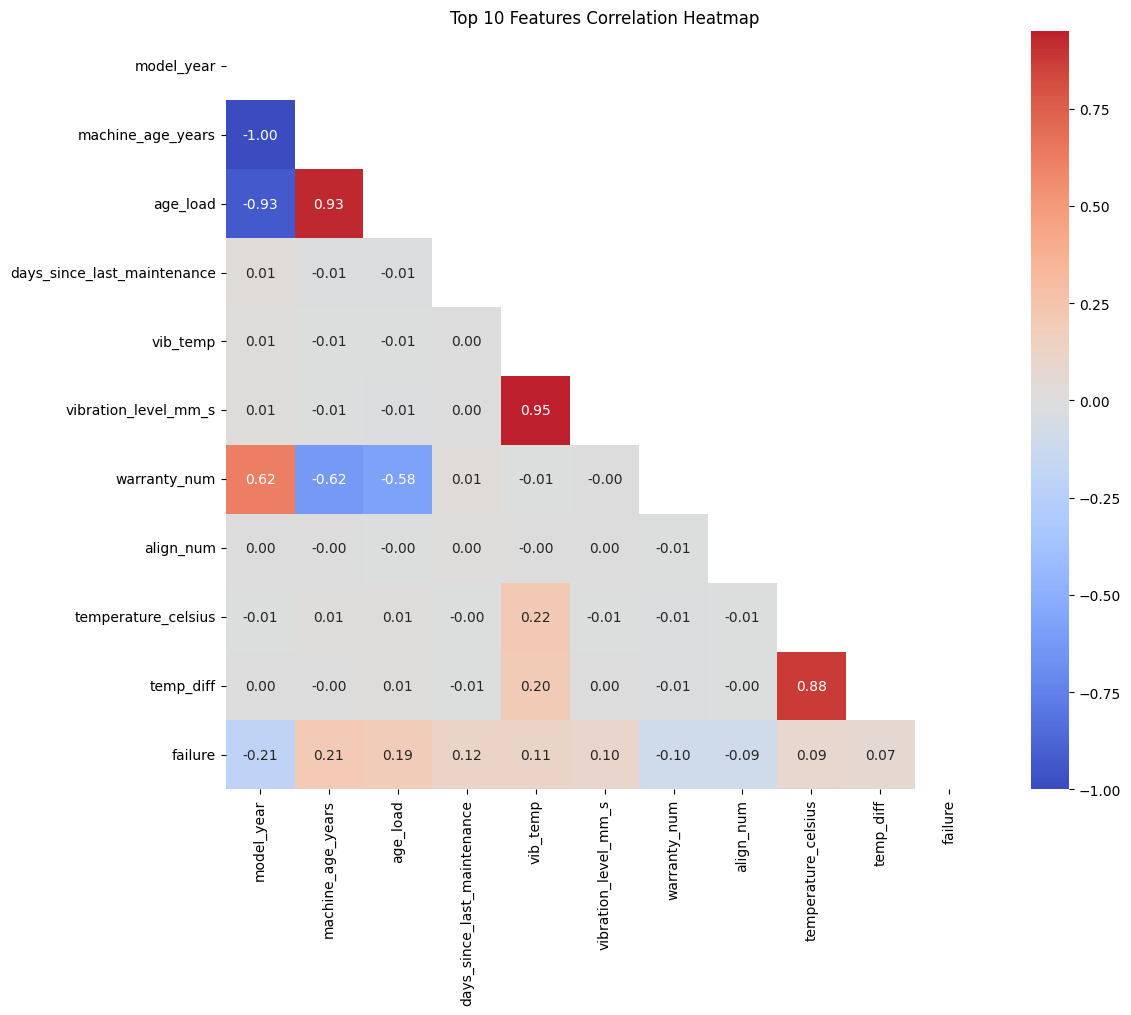

In [9]:
# Top correlations with target
numeric_feats = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_feats].corr()['failure'].abs().sort_values(ascending=False)
top_corrs = correlations[1:11]  

print('Top 10 correlations with failure:')
print(top_corrs.round(3))

# Correlation heatmap (top features)
top10_cols = top_corrs.index.tolist() + ['failure']
plt.figure(figsize=(12, 10))
corr_matrix = df[top10_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Top 10 Features Correlation Heatmap')
plt.tight_layout()
plt.show()

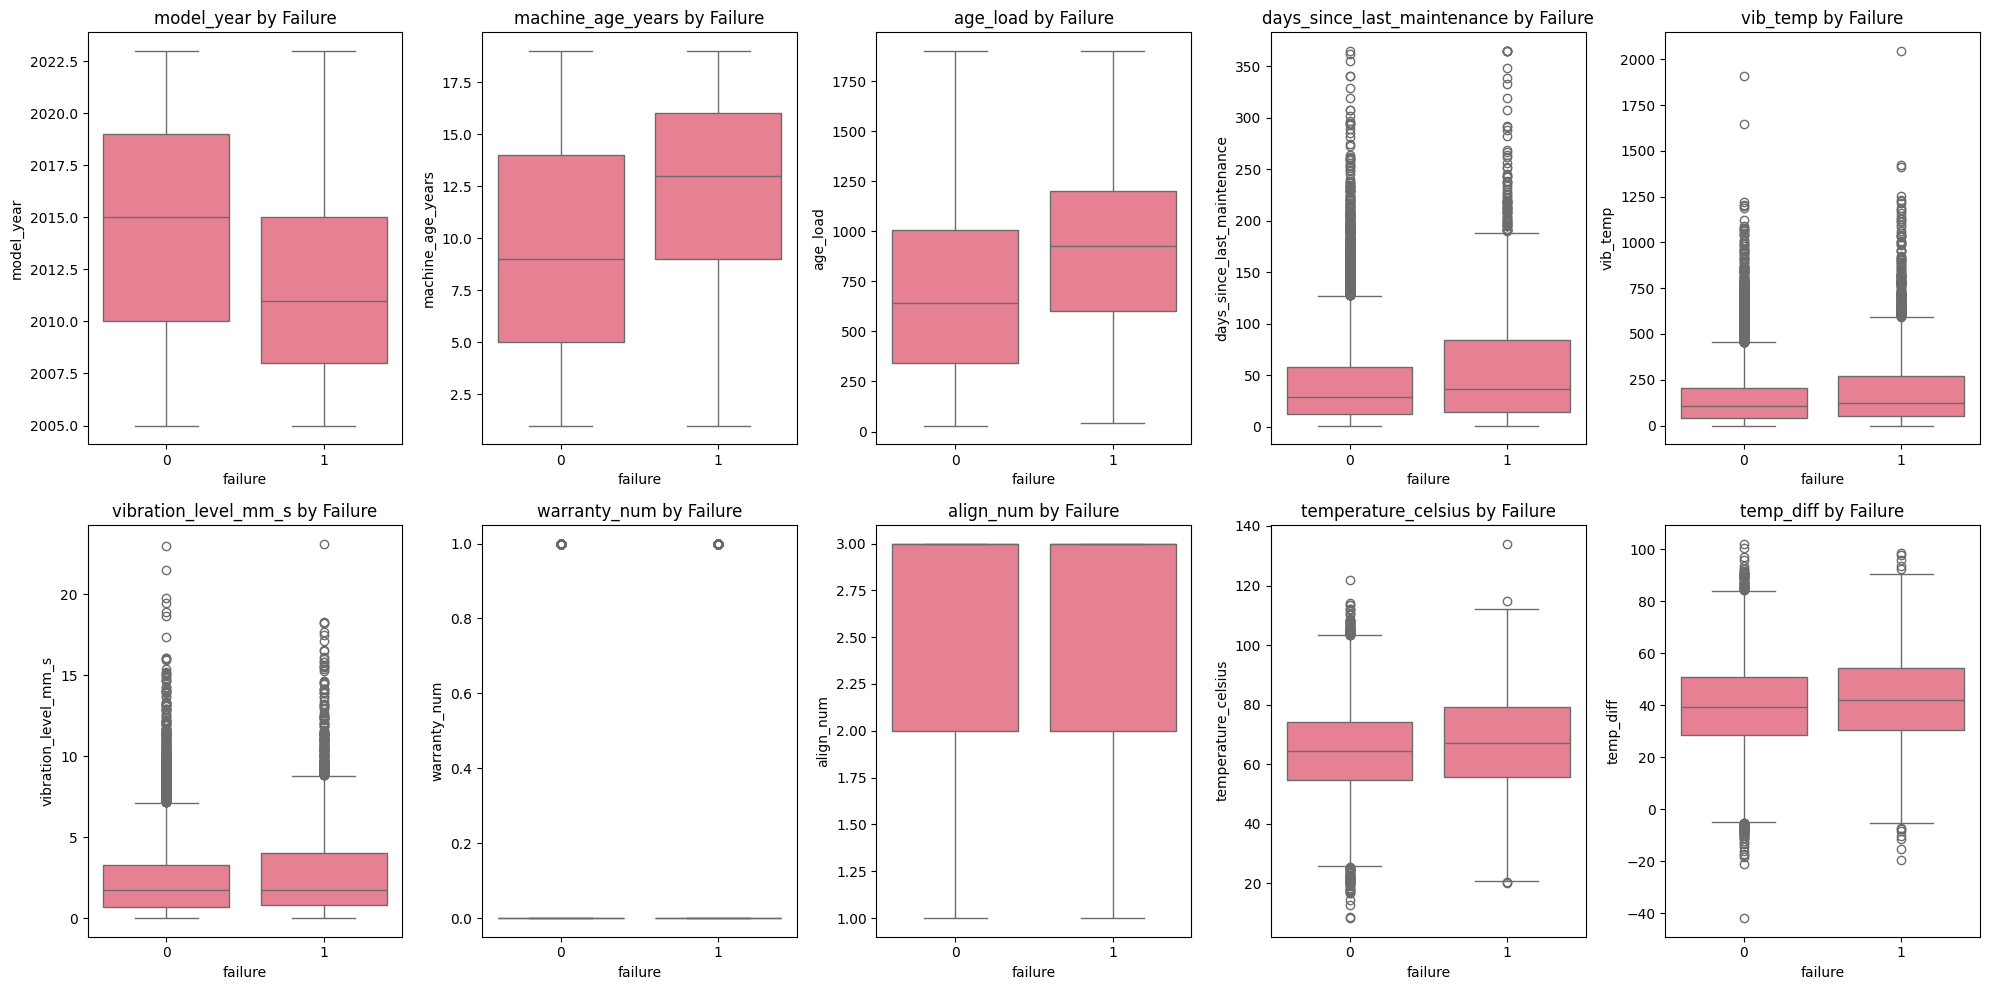

In [10]:
# Boxplots: Top features by failure
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()

for i, feat in enumerate(top_corrs.head(10).index):
    sns.boxplot(data=df, x='failure', y=feat, ax=axes[i])
    axes[i].set_title(f'{feat} by Failure')

plt.tight_layout()
plt.show()

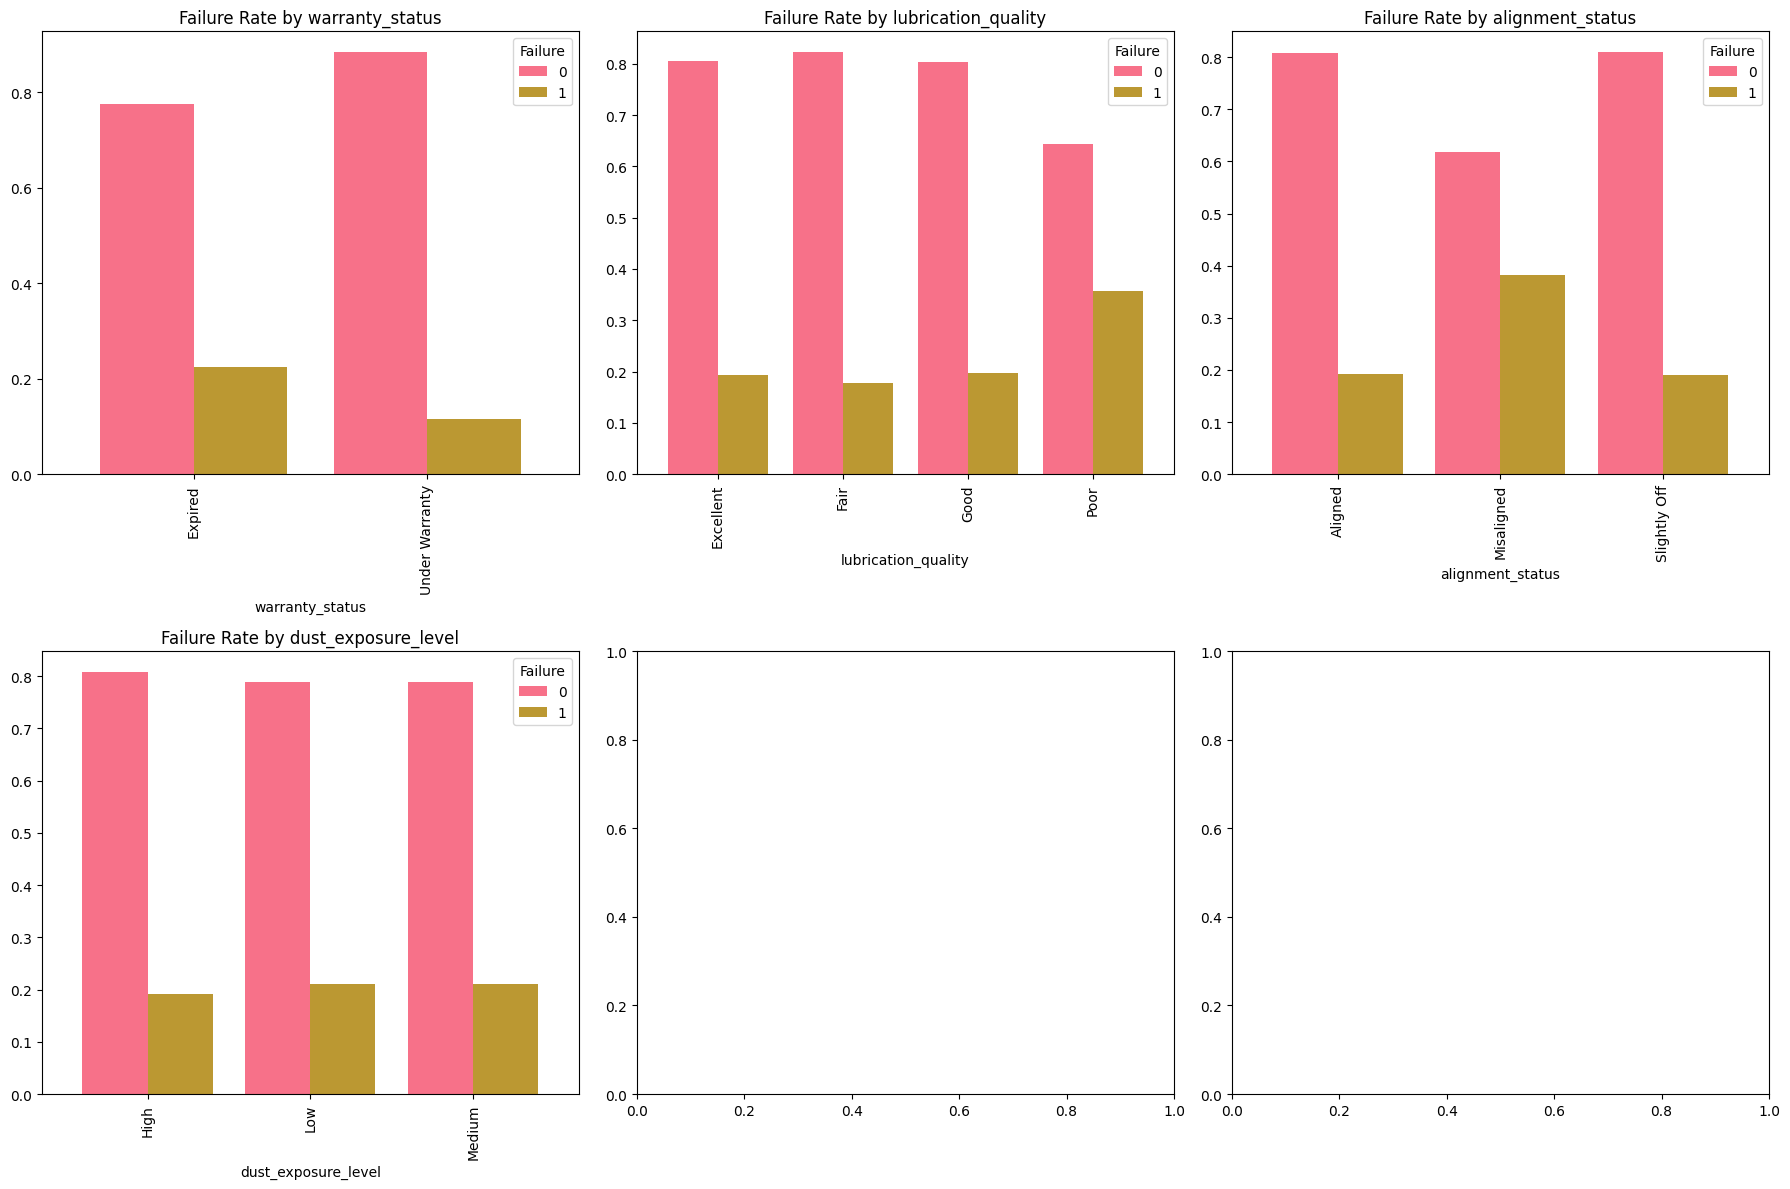

In [ ]:
# Categorical crosstabs
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
cats = ['warranty_status', 'lubrication_quality', 'alignment_status', 'dust_exposure_level']

for i, cat in enumerate(cats):
    if i < 6:
        crosstab = pd.crosstab(df[cat], df['failure'], normalize='index')
        crosstab.plot(kind='bar', ax=axes.flat[i], width=0.8)
        axes.flat[i].set_title(f'Failure Rate by {cat}')
        axes.flat[i].legend(title='Failure')

plt.tight_layout()
plt.show()

## 6. Key Insights Summary

**Data Understanding:** ~15k records, imbalanced target (~10% failures), missing values handled.

**Feature Engineering:** Created temp_diff, maint_ratio, vib_temp, age_load, power_norm + categorical mappings.

**Validated Hypotheses:**
- Vibration significantly higher in failures (p<0.05)
- Older machines have higher failure rates (chi p<0.05)
- Days since maintenance correlates with failure
- Poor lubrication significantly increases risk

**Top Correlated Features:** vibration_level, days_since_maintenance, temperature_celsius, etc.

**EDA Insights:** Clear separation in boxplots for key sensors; categorical factors like lubrication/alignment show risk patterns.